# 03. 세션 마트 EDA

## 분석 개요

- 목적: 세션 마트 `mart_session`의 분포·기술통계를 확인해 04 퍼널 설계의 입력을 마련한다.
- 데이터 소스: **`mart_session`만** 사용한다(`events` 직접 조회 없음). 처리 방침 원천은 `docs/metrics.md`.
- 방식: 집계는 전부 SQL(`sql/03_mart_eda.sql`), 노트북은 소량 결과만 받아 확인·시각화한다.
- 범위: **분포·기술통계까지만.** 전환율·단계 간 전환 비율은 계산하지 않는다(04 소관). 비율은 유효 세션(또는 사용자) 전체 대비만 사용한다.
- 도달 정의: view·cart·purchase가 세션에 1건 이상 있는지를 각각 독립적으로 집계하며 이벤트 순서와 단계 간 포함 관계를 반영하지 않는다. 03의 구매 비율은 구매 세션 도달률이고, 04의 순차 전환율과 구분한다.
- 참고: 결과 수치는 셀 실행 출력에서 확정한다(결론은 실행 후 작성).

In [1]:
import os
import re
import time
from pathlib import Path
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}?charset=utf8mb4"
)

In [2]:
def find_sql(name):
    for base in (Path.cwd(), Path.cwd().parent):  # 현재 작업 폴더와 그 상위 폴더 수색
        cand = base / 'sql' / name
        if cand.exists():
            return cand     # 경로 반환
    raise FileNotFoundError(f'sql/{name} 없음 (cwd={Path.cwd()})')

SQL_FILE = find_sql('03_mart_eda.sql')
CACHE_DIR = SQL_FILE.parent.parent / 'cache'

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8') # 전체 파일 로드
    # (?m)로 줄마다 매칭. '-- name: 쿼리명' 줄에서 이름만 (\w+)로 캡처, 설명은 버림
    # 결과: [빈칸, 이름1, 본문1, 이름2, 본문2, ...] 형태로 분리됨
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body) 
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)} # 홀수에는 쿼리 이름, 짝수에는 SQL 본문이 들어가서 딕셔너리 생성

Q = load_queries(SQL_FILE)

def run(name, refresh=False, **kwargs):
    cache_path = CACHE_DIR / f'{name}.parquet'
    if cache_path.exists() and not refresh: 
        try:
            df = pd.read_parquet(cache_path)
            print(f"[{name}] 캐시 로드 · {len(df):,}행")
            return df
        except Exception:
            pass
    t0 = time.time()
    df = pd.read_sql(text(Q[name]), engine, **kwargs)
    elapsed = time.time() - t0
    try:
        CACHE_DIR.mkdir(exist_ok=True)
        df.to_parquet(cache_path, index=False)
        note = '→ 캐시 저장'
    except Exception as e:
        note = f'(캐시 미저장: {type(e).__name__})'
    print(f"[{name}] 실행 {elapsed:.1f}s · {len(df):,}행 {note}")
    return df

---
## 1. 세션 구성 — 방문은 어디까지 가는가

퍼널을 그리기 전에, 세션들이 실제로 어느 단계까지 도달하는지 규모부터 확인한다. 방문의 대부분이 구경에서 끝난다면 퍼널의 무대는 생각보다 좁기 때문이다. 여기서 "도달"은 세션 안에 해당 행동이 1건 이상 있는 것으로 정의하며, 세션 단위로 세고 비율의 분모는 유효 세션 전체다. 세 항목은 유효 세션 전체를 나누는 분류가 아니다 — cart 없이 제거·구매만 있는 세션은 어디에도 속하지 않으며, 이 잔여 세션의 처리는 04의 단계 정의에서 다룬다. 단계 사이의 전환율은 여기서 계산하지 않고 04로 넘긴다.

In [3]:
reach = run('reach_composition') # 유형 도달별 세션 수 (세션 단위)
tot = int(reach['유효세션'].iloc[0])
reach_tbl = pd.DataFrame({
    '구분': ['view만', 'cart 도달', 'purchase 도달'],
    '세션수': [int(reach['view만'].iloc[0]), int(reach['cart_도달'].iloc[0]), int(reach['purchase_도달'].iloc[0])],
})
reach_tbl['유효세션대비_pct'] = (reach_tbl['세션수'] / tot * 100).round(2)
reach_tbl

[reach_composition] 실행 2.8s · 1행 → 캐시 저장


,구분,세션수,유효세션대비_pct
0,view만,3412464,75.84
1,cart 도달,969957,21.56
2,purchase 도달,151801,3.37


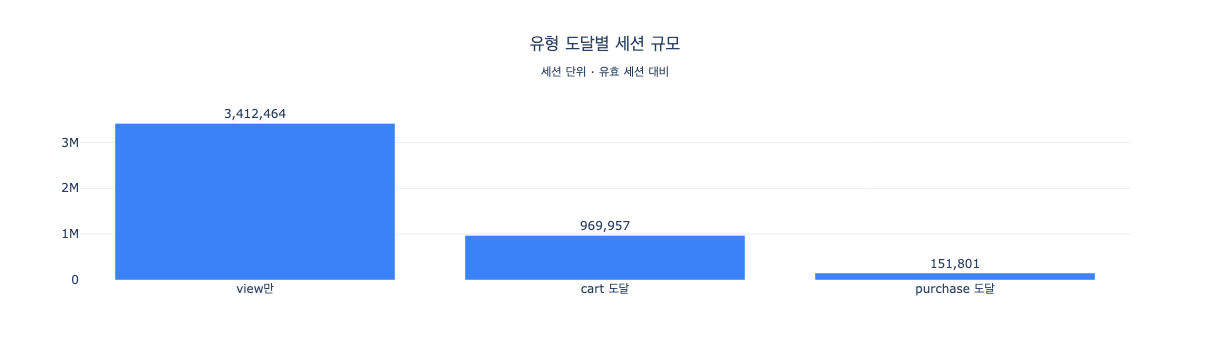

In [4]:
y = reach_tbl['세션수']
fig = go.Figure(go.Bar(
    x=reach_tbl['구분'], y=y, marker_color='#3B82F6',
    text=y.map(lambda v: f"{v:,}"), textposition='outside',
))
fig.update_layout(
    title=dict(text='유형 도달별 세션 규모<br><sub>세션 단위 · 유효 세션 대비</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white', yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

In [5]:
reach_residual = run('reach_residual') # reach 3구분 어디에도 없는 잔여 세션 (수치 확인용)
reach_residual

[reach_residual] 실행 2.3s · 1행 → 캐시 저장


,담기구매없이_제거만있는세션,그중_조회도있음,그중_제거만,전체유효세션
0,87927.0,49612.0,38315.0,4499479


---
## 2. 세션 길이 — 방문은 얼마나 이어지는가

방문이 어느 단계까지 가는지 봤으니, 이제 그 방문이 시간과 활동량으로 얼마나 이어지는지 확인한다. 한 번 클릭하고 마는 세션이 많다면 퍼널이 밟힐 여지 자체가 좁기 때문이다. 세션 길이는 첫·마지막 이벤트 간격(duration_sec)과 이벤트 수(total_events) 두 가지로 나눠 보며, 세션 단위로 구간을 묶어 분포를 센다. 이 분포는 04에서 어디까지를 하나의 퍼널 관측 대상으로 볼지 세션 경계를 정하는 입력이 된다.

In [6]:
duration_dist = run('duration_dist') # 세션지속시간대별 세션 수
duration_dist

[duration_dist] 실행 1.6s · 6행 → 캐시 저장


,구간,세션수
0,0초,2909818
1,<=1분,379217
2,1-5분,457700
3,5-30분,500459
4,30-60분,113946
5,1시간-1일,138339


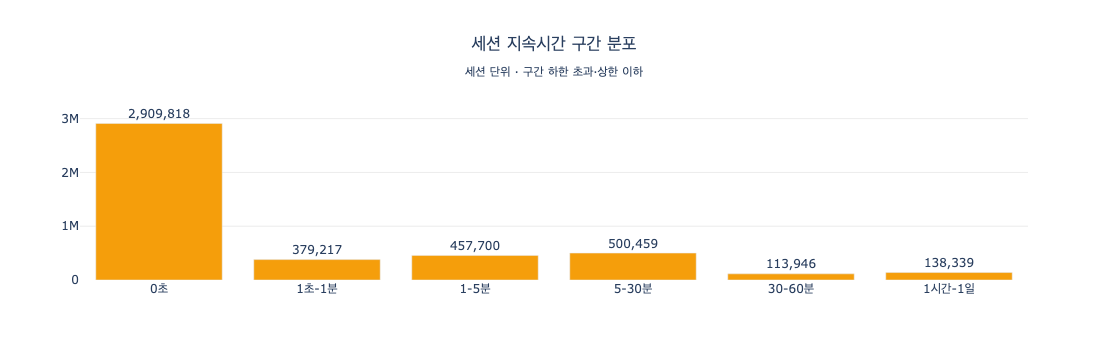

In [7]:
dur_label = {'0초': '0초', '<=1분': '1초-1분'}
duration_dist['구간'] = duration_dist['구간'].replace(dur_label)

y = duration_dist['세션수']
fig = go.Figure(go.Bar(
    x=duration_dist['구간'], y=y, marker_color='#F59E0B',
    text=y.map(lambda v: f"{v:,}"), textposition='outside',
))
fig.update_layout(
    title=dict(text='세션 지속시간 구간 분포<br><sub>세션 단위 · 구간 하한 초과·상한 이하</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white', yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

In [8]:
events_dist = run('events_dist') # 이벤트 횟수대별 세션 수
events_dist

[events_dist] 실행 1.9s · 6행 → 캐시 저장


,구간,세션수
0,0,1
1,1,2887064
2,2-3,695651
3,4-10,518952
4,11-50,345883
5,51+,51928


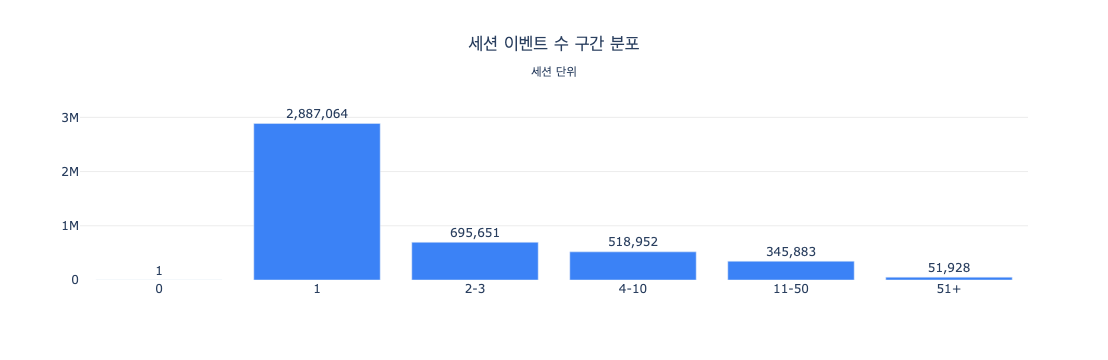

In [9]:
y = events_dist['세션수']
fig = go.Figure(go.Bar(
    x=events_dist['구간'], y=y, marker_color='#3B82F6',
    text=y.map(lambda v: f"{v:,}"), textposition='outside',
))
fig.update_layout(
    title=dict(text='세션 이벤트 수 구간 분포<br><sub>세션 단위</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white', yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

---
## 3. revenue 분포 — 구매는 얼마짜리로 일어나는가

퍼널 맨 아래에 도달한 구매 세션이 어느 금액대에 몰려 있는지 확인한다. 구매가 소액에 집중되는지 고액이 섞이는지에 따라 하단을 값 기준으로 나눌 수 있는지가 갈리기 때문이다. 대상은 구매가 1건 이상인 세션(purchases > 0)이며, 금액대는 로그 스케일 구간으로 묶어 세션 단위로 센다. 이 금액대 분포는 04에서 구매 단계를 값 기준으로 세분화할지 판단하는 입력이 된다.

In [10]:
revenue_dist = run('revenue_dist') # 구매 세션의 금액대별 세션 수

label_map = {
    '0': '0', '(0,10)': '10 미만', '[10,30)': '10-30',
    '[30,100)': '30-100', '[100,300)': '100-300', '300+': '300 이상',
}

revenue_dist['revenue_구간'] = revenue_dist['revenue_구간'].map(label_map)
revenue_dist

[revenue_dist] 실행 1.0s · 5행 → 캐시 저장


,revenue_구간,세션수
0,10 미만,12995
1,10-30,64957
2,30-100,65206
3,100-300,8086
4,300 이상,557


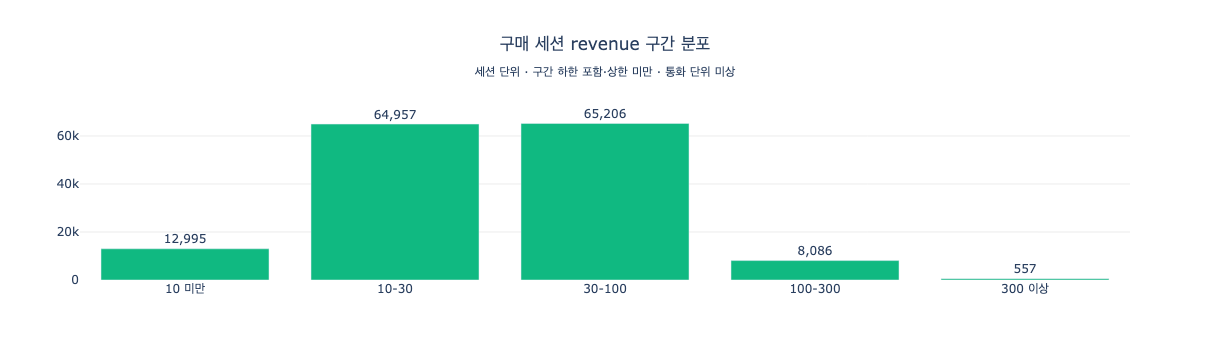

In [11]:
y = revenue_dist['세션수']
fig = go.Figure(go.Bar(
    x=revenue_dist['revenue_구간'], y=y, marker_color='#10B981',
    text=y.map(lambda v: f"{v:,}"), textposition='outside',
))
fig.update_layout(
    title=dict(text='구매 세션 revenue 구간 분포<br><sub>세션 단위 · 구간 하한 포함·상한 미만 · 통화 단위 미상</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white', yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

---
## 4. 시간 추이 — 방문은 언제 몰리는가

세션이 관측 기간 안에서 월별·요일별로 고르게 퍼져 있는지 확인한다. 특정 달이나 요일에 방문이 쏠려 있으면 퍼널 집계가 그 편중에 흔들릴 수 있기 때문이다. 세션의 시작 시각(session_start)을 기준으로 월과 요일에 세션 단위로 집계한다. 이 편중 여부는 04에서 퍼널 집계 기간을 어떻게 나누고 계절성을 통제할지 판단하는 입력이 된다.

In [12]:
monthly_sessions = run('monthly_sessions') # 월별 세션 수
monthly_sessions

[monthly_sessions] 실행 2.7s · 5행 → 캐시 저장


,월,세션수
0,2019-10,865774
1,2019-11,932387
2,2019-12,831007
3,2020-01,953829
4,2020-02,916482


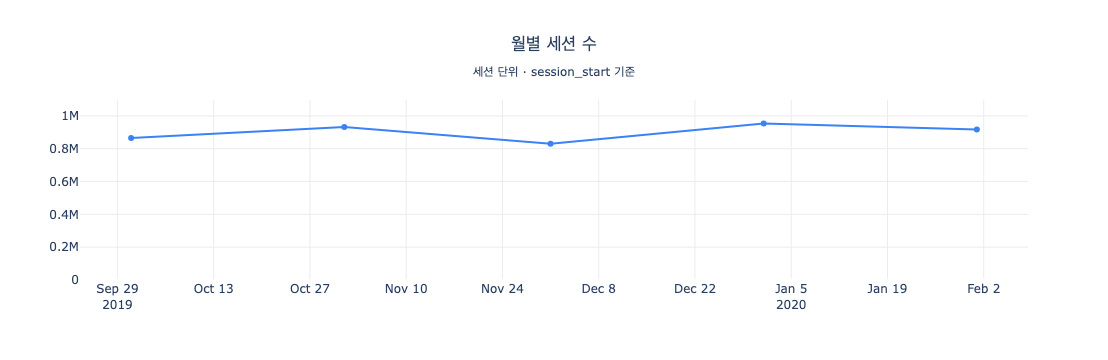

In [13]:
y = monthly_sessions['세션수']
fig = go.Figure(go.Scatter(x=monthly_sessions['월'], y=y, mode='lines+markers', line=dict(color='#3B82F6')))
fig.update_layout(
    title=dict(text='월별 세션 수<br><sub>세션 단위 · session_start 기준</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white', xaxis=dict(gridcolor='#ececec'), yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

In [14]:
dow = run('dow_sessions') # 요일별 세션 수
dow_names = {1: '일', 2: '월', 3: '화', 4: '수', 5: '목', 6: '금', 7: '토'}
dow['요일'] = dow['요일번호'].map(dow_names)
dow

[dow_sessions] 실행 0.9s · 7행 → 캐시 저장


,요일번호,세션수,요일
0,1,593291,일
1,2,659296,월
2,3,666485,화
3,4,680334,수
4,5,674514,목
5,6,646029,금
6,7,579530,토


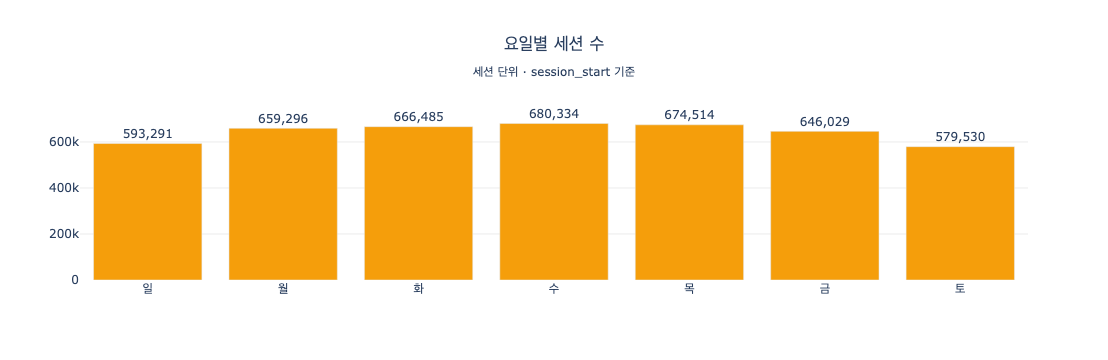

In [15]:
y = dow['세션수']
fig = go.Figure(go.Bar(
    x=dow['요일'], y=y, marker_color='#F59E0B',
    text=y.map(lambda v: f"{v:,}"), textposition='outside',
))
fig.update_layout(
    title=dict(text='요일별 세션 수<br><sub>세션 단위 · session_start 기준</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white', yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

---
## 5. 사용자 — 방문과 구매는 얼마나 반복되는가

지금까지 세션을 봤다면, 여기서는 한 사용자가 몇 번이나 다시 오고 몇 번이나 사는지 확인한다. 반복 방문과 반복 구매의 규모가 크지 않다면 사용자 단위 퍼널이나 재방문 기반 분석의 무대가 좁기 때문이다. 마트를 기준으로 사용자당 세션 수와 사용자당 구매 세션 수를 사용자 단위로 구간을 나눠 센다. 여기서 나오는 1회 방문 사용자 비중과 구매 경험 사용자 규모가 04의 사용자 단위 퍼널과 05의 모수(분석 대상 규모)를 가늠하는 재료가 된다.

In [16]:
user_session_count_dist = run('user_session_count_dist') # 세션 횟수별 사용자 수
user_session_count_dist

[user_session_count_dist] 실행 1.5s · 4행 → 캐시 저장


,구간,사용자수
0,1,1083600
1,2-3,350757
2,4-10,144285
3,11+,55234


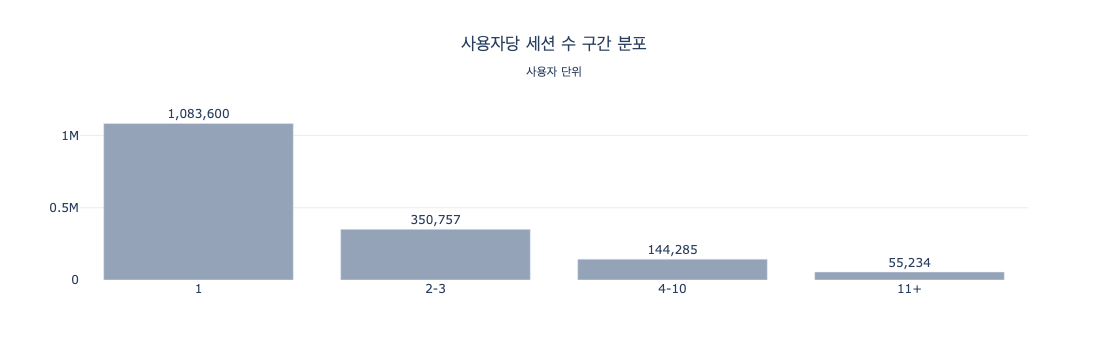

In [17]:
y = user_session_count_dist['사용자수']
fig = go.Figure(go.Bar(
    x=user_session_count_dist['구간'], y=y, marker_color='#94A3B8',
    text=y.map(lambda v: f"{v:,}"), textposition='outside',
))
fig.update_layout(
    title=dict(text='사용자당 세션 수 구간 분포<br><sub>사용자 단위</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white', yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

In [18]:
user_purchase_session_dist = run('user_purchase_session_dist') # 구매 세션 횟수별 사용자 수
user_purchase_session_dist

[user_purchase_session_dist] 실행 30.6s · 4행 → 캐시 저장


,구간,사용자수
0,0,1525453
1,1,85669
2,2-3,18299
3,4+,4455


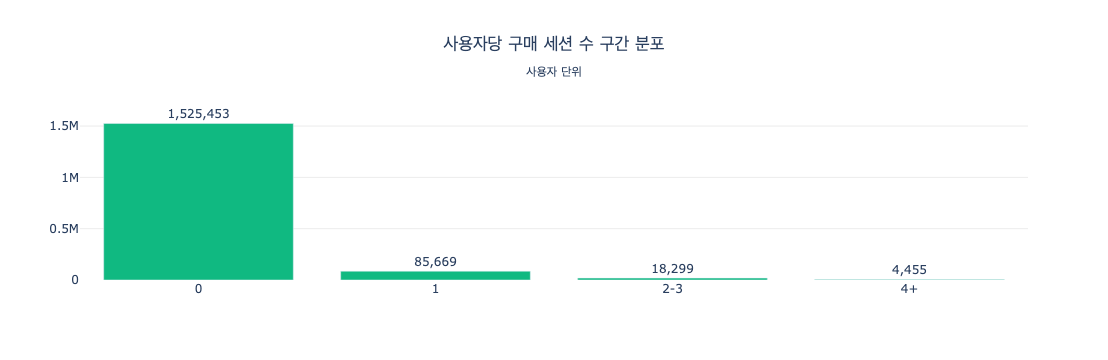

In [19]:
y = user_purchase_session_dist['사용자수']
fig = go.Figure(go.Bar(
    x=user_purchase_session_dist['구간'], y=y, marker_color='#10B981',
    text=y.map(lambda v: f"{v:,}"), textposition='outside',
))
fig.update_layout(
    title=dict(text='사용자당 구매 세션 수 구간 분포<br><sub>사용자 단위</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white', yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

---
## 6. 진입·이탈 유형 — 어디로 들어와 어디서 나가는가

세션이 어떤 행동으로 시작하고 어떤 행동으로 끝나는지 확인한다. 세션마다 첫 이벤트(first_event_type)와 마지막 이벤트(last_event_type)를 세션 단위로 집계한다. 두 유형은 session_start·session_end와 동일하게 가격 필터를 적용하지 않은 전체 이벤트 기준의 보조 기술값이며, 동일 시각의 선후는 식별하지 못한다. 04의 순차 퍼널·직접 진입 경로는 이 컬럼이 아니라 price 정책이 반영된 카운트와 순차 플래그로 판정한다.

In [20]:
first_type_dist = run('first_type_dist') # 첫 이벤트 타입 분포
first_type_dist

[first_type_dist] 실행 2.4s · 4행 → 캐시 저장


,first_event_type,세션수
0,view,4002995
1,cart,357063
2,remove_from_cart,122480
3,purchase,16941


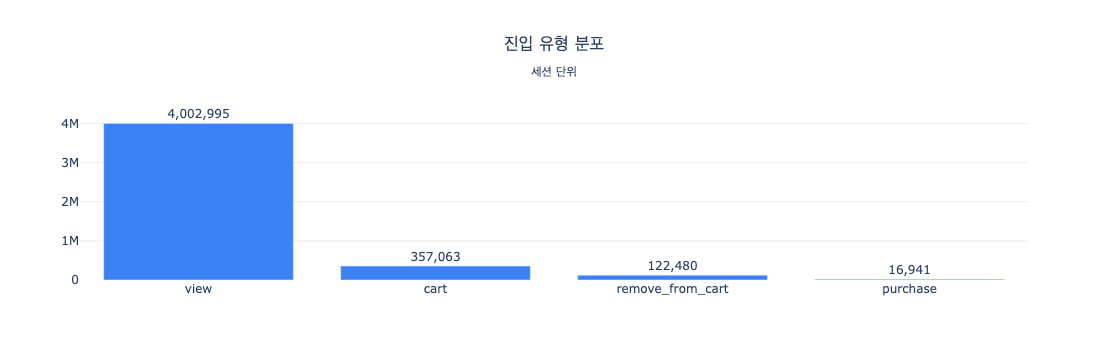

In [21]:
y = first_type_dist['세션수']
fig = go.Figure(go.Bar(
    x=first_type_dist['first_event_type'], y=y, marker_color='#3B82F6',
    text=y.map(lambda v: f"{v:,}"), textposition='outside',
))
fig.update_layout(
    title=dict(text='진입 유형 분포<br><sub>세션 단위</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white', yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

In [22]:
last_type_dist = run('last_type_dist') # 마지막 이벤트 타입 분포
last_type_dist

[last_type_dist] 실행 2.4s · 4행 → 캐시 저장


,last_event_type,세션수
0,view,3678605
1,cart,497646
2,remove_from_cart,183809
3,purchase,139419


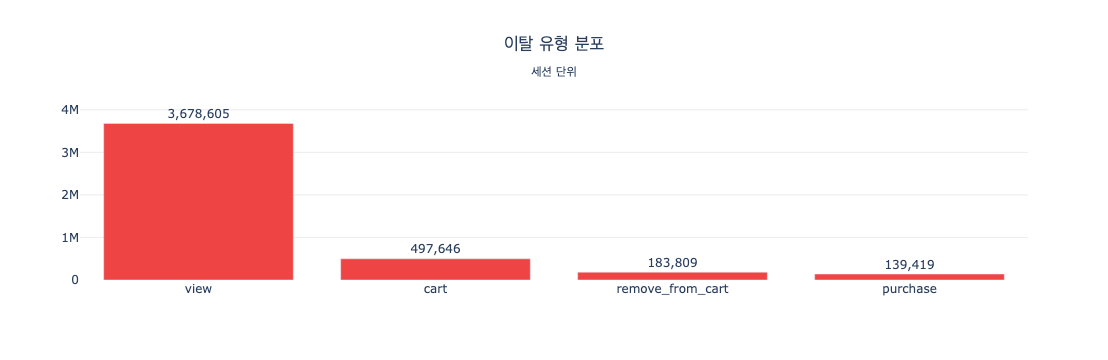

In [23]:
y = last_type_dist['세션수']
fig = go.Figure(go.Bar(
    x=last_type_dist['last_event_type'], y=y, marker_color='#EF4444',
    text=y.map(lambda v: f"{v:,}"), textposition='outside',
))
fig.update_layout(
    title=dict(text='이탈 유형 분포<br><sub>세션 단위</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white', yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

> ### 섹션 결론
>
> - 유효 세션 4,499,479개 중 view만 있는 세션은 3,412,464개(75.84%), cart 도달 세션은 969,957개(21.56%), purchase 도달 세션은 151,801개(3.37%)다. 세 집계는 이벤트 순서를 반영하지 않고 서로 독립적이므로 순차 전환율이나 단계 간 드랍오프를 의미하지 않는다. cart·purchase 없이 remove_from_cart가 포함된 잔여 세션 87,927개는 어느 구분에도 속하지 않으며, 04에서 순차 플래그와 이벤트 카운트를 기준으로 경로를 별도 정의한다.
> - duration 0초 세션은 2,909,818개(64.67%), 단일 이벤트 세션은 2,887,064개(64.16%)로 비중이 유사하다. 다만 duration은 체류시간이 아니라 첫·마지막 이벤트 간격이므로 세션 길이 해석에는 이벤트 수(total_events)를 병용한다.
> - 구매 경험 사용자는 전체 1,633,876명 중 108,423명(6.64%)으로 소수다. 이 규모는 재방문 기반 구매 여정 분석(05)의 존폐를 판단하는 재료로 인계한다.
> - 월별 세션은 2019-12 831,007개에서 2020-01 953,829개 사이로 큰 급변 없이 분포하고, 요일별로도 과도한 쏠림이 관찰되지 않는다. 04 퍼널 집계가 특정 기간 편중에 크게 좌우될 가능성은 낮다.
> - 전체 이벤트 기준 first_event_type은 view가 4,002,995세션으로 최다이며 cart 357,063·purchase 16,941세션으로 분포한다. last_event_type도 view가 3,678,605세션으로 최다이며 cart 497,646·remove_from_cart 183,809·purchase 139,419세션으로 분포한다. 이는 세션 경계의 보조 기술값이며 직접 진입이나 순차 이탈 판정값은 아니다. 04의 경로·이탈은 price 정책이 반영된 이벤트 카운트와 순차 플래그로 판정한다.
>
> (각주) total_events=0 세션 1건은 전 이벤트가 음수 가격이라 카운트에서 제외된 방침의 부산물로, 지표 영향 없음.